<div style="background-color:#1E3A5F; padding:30px 40px; border-radius:10px; margin-bottom:20px">
  <h1 style="color:#FFFFFF; font-family:Trebuchet MS; margin:0 0 8px 0;">Encontro 04 — Primeiros Classificadores</h1>
  <p style="color:#8FB8D8; font-size:14px; margin:0;">INAR230007 · Inteligência Artificial: Aprendizado de Máquinas · Aula Prática</p>
  <hr style="border-color:#0D9488; margin:16px 0 12px 0;">
  <p style="color:#E2EBF5; font-size:13px; margin:0;"><b>O que faremos hoje:</b> Treinar os nossos primeiros classificadores (KNN e Árvore de Decisão), separar dados em treino e teste, gerar uma Matriz de Confusão e ver com os próprios olhos a diferença entre erro de treino e erro de teste.</p>
</div>

## Roteiro da aula

| Etapa | O que faremos |
|-------|---------------|
| **0** | Instalação e importação das bibliotecas |
| **1** | Carregamento e exploração do dataset |
| **2** | Separação treino / teste |
| **3** | Primeiro classificador: K-Nearest Neighbors (KNN) |
| **4** | Segundo classificador: Árvore de Decisão |
| **5** | Matriz de Confusão |
| **6** | Erro de treino vs. erro de teste — vendo o overfitting |
| **7** | Desafio final |

---
## Etapa 0 · Importando as bibliotecas

Antes de qualquer coisa, precisamos importar as ferramentas que vamos usar. Na prática de Machine Learning, quase sempre usamos o mesmo conjunto de bibliotecas:

- `numpy` e `pandas` → manipulação de dados
- `matplotlib` e `seaborn` → visualizações
- `scikit-learn` → os algoritmos de ML

In [ ]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualizações
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Dataset de exemplo
from sklearn.datasets import load_iris

# Separação treino/teste
from sklearn.model_selection import train_test_split

# Classificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Métricas
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Etapa 1 · Conhecendo o dataset

Vamos usar o **Iris Dataset** — um dos datasets mais clássicos de ML, presente em praticamente todo curso introdutório. Ele foi publicado pelo estatístico Ronald Fisher em 1936.

### O problema
Dadas as medições de uma flor de íris, classificar a qual das **3 espécies** ela pertence:

| Espécie | Classe |
|---------|--------|
| *Iris setosa* | 0 |
| *Iris versicolor* | 1 |
| *Iris virginica* | 2 |

### As features (atributos de entrada)
Cada flor é descrita por **4 medições** em centímetros:
- Comprimento da sépala
- Largura da sépala
- Comprimento da pétala
- Largura da pétala

In [ ]:
# Carregando o dataset
df = pd.read_csv('/content/drive/MyDrive/wine-quality/winequality-red.csv', sep=';')

def classify_quality(q):
    if q <= 5:
        return 'Ruim'
    elif q == 6:
        return 'Medio'
    else:
        return 'Bom'


df['quality_label'] = df['quality'].apply(classify_quality)

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Ruim
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,Ruim
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,Ruim
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,Medio
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,Ruim
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,Ruim
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,Ruim
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,Bom
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,Bom
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,Ruim


In [ ]:
# Quantas amostras temos por classe?
print("Distribuição das classes:")
print(df['quality_label'].value_counts())

Distribuição das classes:
quality_label
Ruim     744
Medio    638
Bom      217
Name: count, dtype: int64


**Observe:** temos 50 amostras por espécie — um dataset **balanceado**. Isso facilita o treinamento e a avaliação dos modelos.

In [ ]:
# Estatísticas descritivas
num_cols = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'quality'
]

str_cols = ['quality_label']
df[num_cols].describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

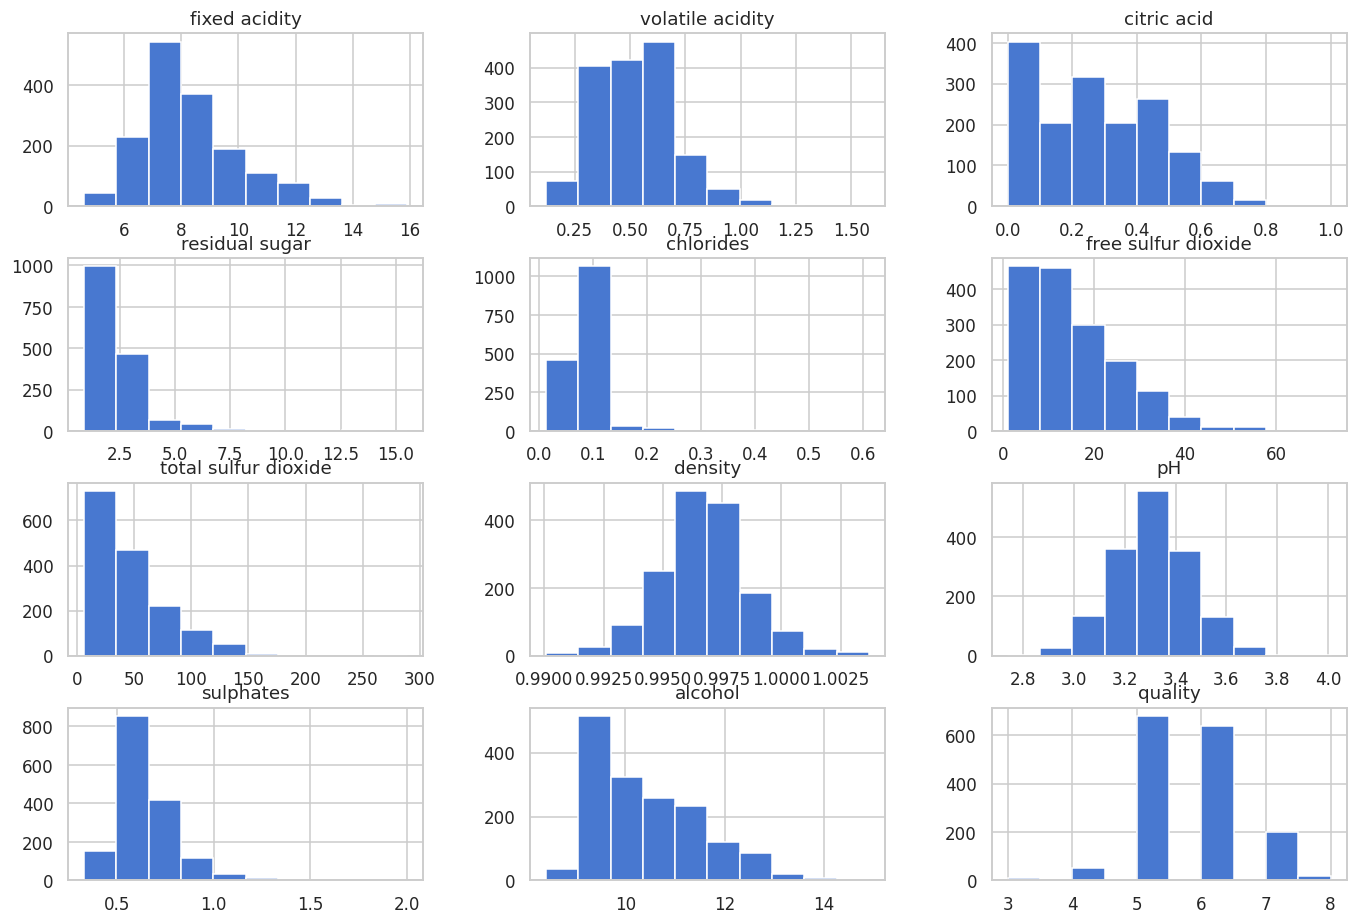

In [ ]:
df[num_cols].hist(figsize=(15,10), bins=10)

{'whiskers': [<matplotlib.lines.Line2D at 0x7b03214a3c50>,
 'caps': [<matplotlib.lines.Line2D at 0x7b03214cc260>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b03214a39b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7b03214cc830>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b03214ccb60>],
 'means': []}

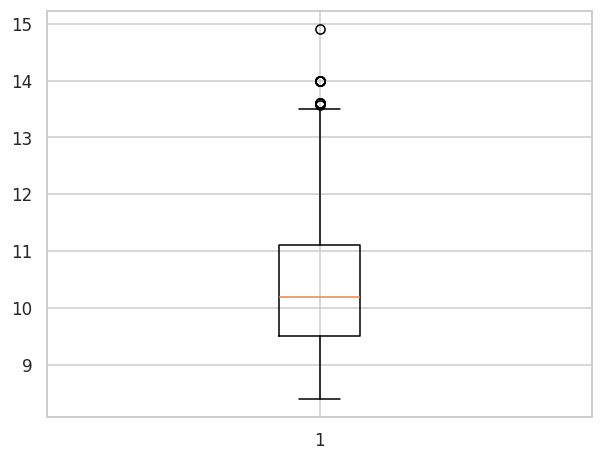

In [ ]:
plt.boxplot(df['alcohol'].dropna())

In [ ]:
#plt.hist(penguins_dataset['culmen_length_mm'].dropna(), bins=25)

---
## Etapa 2 · Separação Treino / Teste

Vimos na aula teórica (Encontro 03) que não podemos avaliar o modelo nos mesmos dados em que ele treinou. Agora vamos fazer isso na prática.

A função `train_test_split` do scikit-learn faz essa separação automaticamente.

## Pré-processamento

Que é limpar a nossa base de dados! Como assim???

Removendo ou tratando os valores NaN, vazio, None e etc...

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_label         1599 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 162.5+ KB


In [ ]:
wine_df = df.dropna()
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_label         1599 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 162.5+ KB


In [ ]:
# Separando features (X) e target (y)
X = df.drop(columns=str_cols).round(2)      # shape: (150, 4) — as 4 features de cada flor
y = df['quality']    # shape: (150,)   — a classe de cada flor (0, 1 ou 2)

print(f"X (features): {X.shape}  →  {X.shape[0]} amostras, {X.shape[1]} features cada")
print(f"y (target):   {y.shape}  →  {y.shape[0]} rótulos")

X (features): (1599, 12)  →  1599 amostras, 12 features cada
y (target):   (1599,)  →  1599 rótulos


In [ ]:
# Separando em treino (80%) e teste (20%)
# random_state=42 garante que você e eu teremos os mesmos resultados (reprodutibilidade)
# stratify=y garante que a proporção das classes seja mantida nos dois conjuntos

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.33,    # 20% para teste
    random_state=42,  # semente aleatória — garante reprodutibilidade
    stratify=y       # mantém a proporção das classes
)

print(f"Treino:  {X_treino.shape[0]} amostras")
print(f"Teste:   {X_teste.shape[0]} amostras")
print()
print("Distribuição no treino:", dict(zip(*np.unique(y_treino, return_counts=True))))
print("Distribuição no teste: ", dict(zip(*np.unique(y_teste,  return_counts=True))))

Treino:  1071 amostras
Teste:   528 amostras

Distribuição no treino: {np.int64(3): np.int64(7), np.int64(4): np.int64(36), np.int64(5): np.int64(456), np.int64(6): np.int64(427), np.int64(7): np.int64(133), np.int64(8): np.int64(12)}
Distribuição no teste:  {np.int64(3): np.int64(3), np.int64(4): np.int64(17), np.int64(5): np.int64(225), np.int64(6): np.int64(211), np.int64(7): np.int64(66), np.int64(8): np.int64(6)}


<div style="background-color:#EFF6FF; border-left:4px solid #2563EB; padding:12px 16px; border-radius:4px;">

**💡 Ponto de atenção:** O parâmetro `stratify=y` é importante! Sem ele, por pura sorte, o conjunto de teste poderia acabar com poucos (ou nenhum) exemplos de uma das classes. Com ele, garantimos que a proporção de cada espécie é preservada.

**Regra de ouro:** A partir daqui, o conjunto de teste (`X_teste`, `y_teste`) **não deve ser usado** para nada além da avaliação final. Ele simula dados do mundo real que o modelo nunca viu.
</div>

---
## Etapa 3 · Primeiro Classificador: KNN

### Como funciona o K-Nearest Neighbors?

A ideia é simples: para classificar um novo ponto, olhe para os **K vizinhos mais próximos** no espaço de features e tome a **classe mais comum** entre eles.

```
Ponto novo: [5.1, 3.5, 1.4, 0.2]

Com K=3, encontra os 3 vizinhos mais próximos:
  → Vizinho 1: setosa
  → Vizinho 2: setosa
  → Vizinho 3: versicolor

Decisão: setosa (maioria vence)
```

**Parâmetro principal:** `n_neighbors` (= K) — quantos vizinhos considerar.
- K pequeno → modelo mais complexo, maior risco de overfitting
- K grande → modelo mais simples, maior risco de underfitting

In [ ]:
# Criando e treinando o modelo KNN com K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino, y_treino)  # <-- aqui o modelo "aprende" com os dados de treino

print("✅ Modelo KNN treinado!")

✅ Modelo KNN treinado!


In [ ]:
# Fazendo previsões
y_pred_knn = knn.predict(X_teste)  # aplica o modelo nos dados de TESTE

# Comparando as primeiras 15 previsões com os valores reais
# nomes = penguins_df.species.unique()
# print(f"{'Real':<20} {'Previsto':<20} {'Acerto?'}")
# print("-" * 50)
# for real, prev in zip(y_teste[:15], y_pred_knn[:15]):
#     acerto = "✅" if real == prev else "❌"
#     print(f"{nomes[real]:<20} {nomes[prev]:<20} {acerto}")

In [ ]:
knn.kneighbors()

(array([[1.63395226, 1.63395226, 1.69531708, 1.93150201, 1.97679033],
        [0.        , 1.07382494, 1.68044637, 1.909424  , 2.11681364],
        [0.        , 4.22950352, 4.24696362, 4.94828253, 4.94828253],
        ...,
        [0.        , 1.02166531, 1.246836  , 1.48057421, 1.49392102],
        [0.        , 2.01987623, 2.01987623, 2.01987623, 2.75632001],
        [0.        , 2.93325757, 3.18441517, 3.18441517, 3.35007463]]),
 array([[ 362,  321,  167,  883,  388],
        [ 870,   20,  385,  706,  646],
        [ 520,  254, 1037,  743,  760],
        ...,
        [ 864,  767,  375,  847,  880],
        [  56,  781,  212,  300,  701],
        [ 223,  452,  644,  361, 1021]]))

In [ ]:
y_pred_knn

array([6, 7, 6, 6, 6, 5, 6, 5, 6, 5, 5, 5, 5, 5, 6, 6, 6, 6, 5, 5, 5, 5,
       5, 5, 6, 5, 6, 5, 5, 7, 5, 5, 6, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5,
       5, 5, 6, 5, 5, 6, 6, 7, 5, 5, 7, 6, 6, 6, 5, 6, 5, 6, 5, 5, 5, 6,
       6, 6, 5, 5, 5, 5, 5, 5, 5, 6, 7, 5, 6, 6, 6, 5, 6, 5, 5, 6, 7, 6,
       6, 5, 6, 5, 6, 5, 6, 6, 6, 6, 7, 5, 6, 5, 6, 5, 7, 6, 6, 6, 5, 7,
       5, 5, 5, 6, 5, 5, 5, 6, 5, 6, 5, 5, 6, 5, 5, 6, 5, 5, 6, 5, 6, 6,
       5, 5, 6, 6, 6, 5, 7, 6, 6, 6, 5, 7, 6, 6, 5, 6, 5, 6, 5, 5, 5, 5,
       5, 5, 6, 6, 6, 5, 6, 5, 7, 7, 5, 6, 6, 6, 5, 5, 6, 6, 5, 3, 6, 5,
       6, 7, 5, 6, 5, 6, 6, 6, 5, 6, 6, 5, 5, 6, 6, 7, 6, 6, 5, 6, 5, 5,
       6, 6, 7, 6, 6, 5, 5, 5, 5, 6, 6, 6, 6, 5, 5, 5, 5, 6, 5, 5, 5, 5,
       6, 5, 5, 5, 6, 6, 5, 5, 7, 4, 6, 6, 5, 5, 5, 6, 6, 6, 6, 5, 5, 6,
       6, 5, 6, 6, 6, 6, 6, 5, 6, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 5, 5, 7,
       6, 5, 6, 6, 6, 5, 5, 6, 6, 5, 5, 6, 6, 6, 5, 5, 6, 5, 6, 6, 6, 5,
       5, 5, 5, 6, 6, 5, 5, 5, 5, 6, 6, 5, 5, 5, 5,

In [ ]:
X_teste

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
102,8.1,0.55,0.18,1.9,0.08,13.0,35.0,1.0,3.30,0.59,9.0,6
495,10.7,0.35,0.53,2.6,0.07,5.0,16.0,1.0,3.15,0.65,11.0,8
1576,8.0,0.30,0.63,1.6,0.08,16.0,29.0,1.0,3.30,0.78,10.8,6
1529,7.1,0.69,0.08,2.1,0.06,42.0,52.0,1.0,3.42,0.60,10.2,6
1268,6.9,0.41,0.31,2.0,0.08,21.0,51.0,1.0,3.47,0.55,9.5,6
...,...,...,...,...,...,...,...,...,...,...,...,...
716,8.0,0.43,0.36,2.3,0.08,10.0,48.0,1.0,3.34,0.46,9.4,5
416,10.6,0.48,0.64,2.2,0.11,6.0,20.0,1.0,3.26,0.66,11.7,6
465,10.0,0.29,0.40,2.9,0.10,10.0,26.0,1.0,3.48,0.91,9.7,5
1303,8.0,0.28,0.44,1.8,0.08,28.0,68.0,1.0,3.36,0.66,11.2,5


In [ ]:
y_pred_knn

array([6, 7, 6, 6, 6, 5, 6, 5, 6, 5, 5, 5, 5, 5, 6, 6, 6, 6, 5, 5, 5, 5,
       5, 5, 6, 5, 6, 5, 5, 7, 5, 5, 6, 5, 5, 5, 5, 5, 6, 5, 5, 5, 5, 5,
       5, 5, 6, 5, 5, 6, 6, 7, 5, 5, 7, 6, 6, 6, 5, 6, 5, 6, 5, 5, 5, 6,
       6, 6, 5, 5, 5, 5, 5, 5, 5, 6, 7, 5, 6, 6, 6, 5, 6, 5, 5, 6, 7, 6,
       6, 5, 6, 5, 6, 5, 6, 6, 6, 6, 7, 5, 6, 5, 6, 5, 7, 6, 6, 6, 5, 7,
       5, 5, 5, 6, 5, 5, 5, 6, 5, 6, 5, 5, 6, 5, 5, 6, 5, 5, 6, 5, 6, 6,
       5, 5, 6, 6, 6, 5, 7, 6, 6, 6, 5, 7, 6, 6, 5, 6, 5, 6, 5, 5, 5, 5,
       5, 5, 6, 6, 6, 5, 6, 5, 7, 7, 5, 6, 6, 6, 5, 5, 6, 6, 5, 3, 6, 5,
       6, 7, 5, 6, 5, 6, 6, 6, 5, 6, 6, 5, 5, 6, 6, 7, 6, 6, 5, 6, 5, 5,
       6, 6, 7, 6, 6, 5, 5, 5, 5, 6, 6, 6, 6, 5, 5, 5, 5, 6, 5, 5, 5, 5,
       6, 5, 5, 5, 6, 6, 5, 5, 7, 4, 6, 6, 5, 5, 5, 6, 6, 6, 6, 5, 5, 6,
       6, 5, 6, 6, 6, 6, 6, 5, 6, 5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 5, 5, 7,
       6, 5, 6, 6, 6, 5, 5, 6, 6, 5, 5, 6, 6, 6, 5, 5, 6, 5, 6, 6, 6, 5,
       5, 5, 5, 6, 6, 5, 5, 5, 5, 6, 6, 5, 5, 5, 5,

In [ ]:
# Calculando a acurácia
acuracia_knn_treino = accuracy_score(y_treino, knn.predict(X_treino))
acuracia_knn_teste  = accuracy_score(y_teste,  y_pred_knn)

print(f"KNN (K=5)")
print(f"  Acurácia no TREINO: {acuracia_knn_treino:.2%}")
print(f"  Acurácia no TESTE:  {acuracia_knn_teste:.2%}")

KNN (K=5)
  Acurácia no TREINO: 71.34%
  Acurácia no TESTE:  57.95%


### 🤔 Pare e reflita

A diferença entre a acurácia no treino e no teste é o nosso primeiro sinal de **overfitting** (ou da falta dele). Se as duas fossem iguais e muito altas, seria ótimo. Se o teste fosse muito pior que o treino, teríamos overfitting.

Vamos explorar isso mais na Etapa 6.

---
## Etapa 4 · Segundo Classificador: Árvore de Decisão

### Como funciona?

A Árvore de Decisão aprende uma série de **perguntas sobre as features** que levam à classificação correta. Por exemplo:

```
petal length <= 2.45?
├── Sim → Setosa
└── Não → petal width <= 1.75?
           ├── Sim → Versicolor
           └── Não → Virginica
```

**Parâmetro principal:** `max_depth` — profundidade máxima da árvore.
- Sem limite → árvore cresce até separar todos os exemplos de treino (overfitting!)
- Muito pequena → árvore simples demais (underfitting)

Vamos começar com `max_depth=3`.

In [ ]:
# Criando e treinando a Árvore de Decisão
arvore = DecisionTreeClassifier(max_depth=3, random_state=42)
arvore.fit(X_treino, y_treino)

print("✅ Árvore de Decisão treinada!")

# Avaliando
y_pred_arvore = arvore.predict(X_teste)

acuracia_arvore_treino = accuracy_score(y_treino, arvore.predict(X_treino))
acuracia_arvore_teste  = accuracy_score(y_teste,  y_pred_arvore)

print(f"\nÁrvore de Decisão (max_depth=3)")
print(f"  Acurácia no TREINO: {acuracia_arvore_treino:.2%}")
print(f"  Acurácia no TESTE:  {acuracia_arvore_teste:.2%}")

✅ Árvore de Decisão treinada!

Árvore de Decisão (max_depth=3)
  Acurácia no TREINO: 100.00%
  Acurácia no TESTE:  100.00%


NameError: name 'iris' is not defined

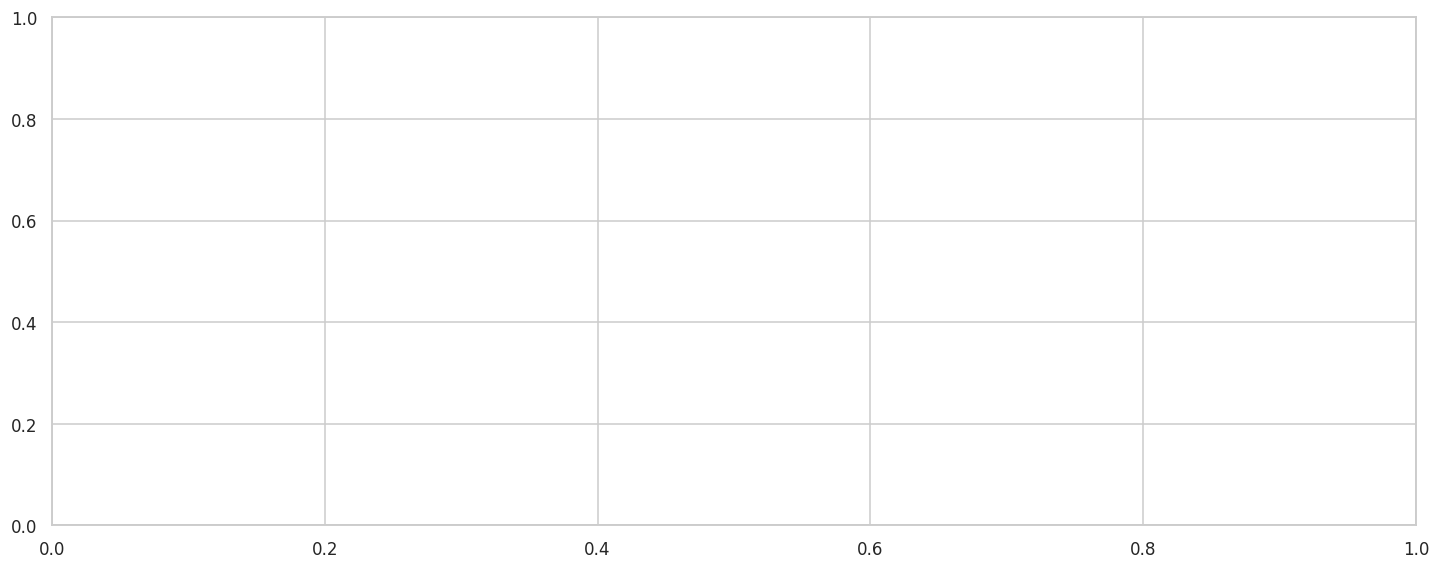

In [ ]:
# Visualizando a árvore — esse é um dos grandes pontos fortes das árvores de decisão:
# elas são interpretáveis!

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    arvore,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=False
)
plt.title('Árvore de Decisão (max_depth=3)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Leia a árvore de cima para baixo:**
- Cada **nó interno** faz uma pergunta: `feature <= valor?`
- Ir para a **esquerda** significa "Sim"
- Ir para a **direita** significa "Não"
- Cada **folha** (nó final) contém a classe predita e o número de amostras de treino que caíram ali

**Qual feature é a mais importante?** Aquela na raiz da árvore — o algoritmo escolheu ela como o melhor ponto de partida para separar as classes.

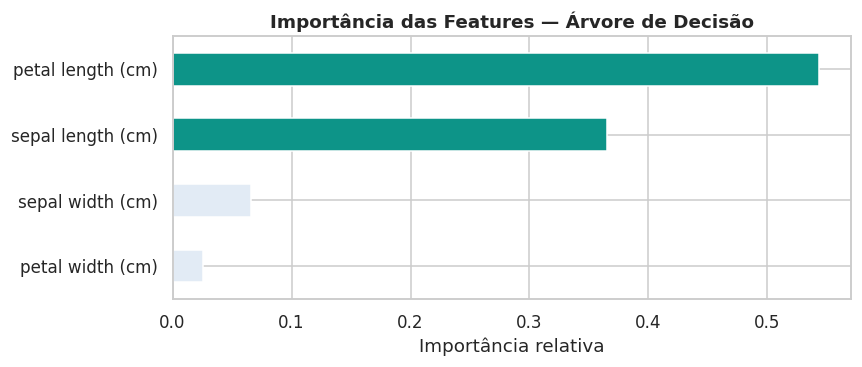


Importâncias:
  petal length (cm)              0.543
  sepal length (cm)              0.365
  sepal width (cm)               0.066
  petal width (cm)               0.025


In [ ]:
# Importância das features
importancias = pd.Series(arvore.feature_importances_, index=iris.feature_names)
importancias = importancias.sort_values(ascending=True)

cores_barras = ['#E2EBF5' if v < 0.3 else '#0D9488' for v in importancias]

fig, ax = plt.subplots(figsize=(8, 3.5))
importancias.plot.barh(ax=ax, color=cores_barras)
ax.set_xlabel('Importância relativa')
ax.set_title('Importância das Features — Árvore de Decisão', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nImportâncias:")
for feat, imp in importancias.sort_values(ascending=False).items():
    print(f"  {feat:<30} {imp:.3f}")

---
## Etapa 5 · Matriz de Confusão

A acurácia nos diz **quantos** acertamos, mas não **onde** erramos. A **Matriz de Confusão** resolve isso.

Cada linha representa a classe **real**; cada coluna representa a classe **prevista**.
Os valores na diagonal principal são os **acertos**. Fora da diagonal são os **erros**.

```
                   Previsto
              Set  Ver  Vir
Real  Set  [ 10    0    0 ]   ← todos os setosa foram classificados corretamente
      Ver  [  0    9    1 ]   ← 1 versicolor foi classificado como virginica
      Vir  [  0    0   10 ]   ← todos os virginica foram classificados corretamente
```

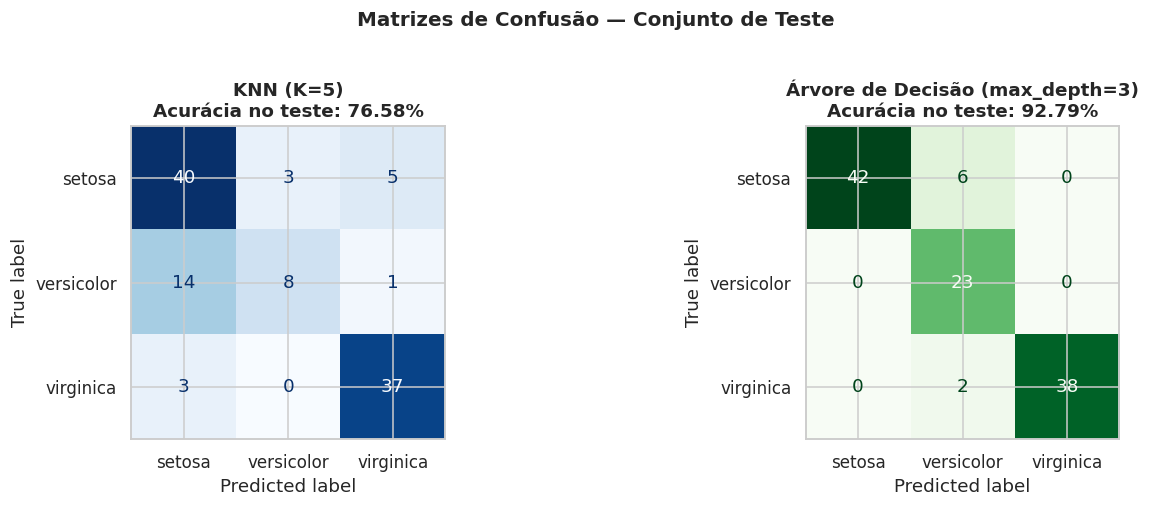

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# KNN
cm_knn = confusion_matrix(y_teste, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(cm_knn, display_labels=iris.target_names)
disp_knn.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'KNN (K=5)\nAcurácia no teste: {acuracia_knn_teste:.2%}',
                  fontweight='bold')

# Árvore de Decisão
cm_arvore = confusion_matrix(y_teste, y_pred_arvore)
disp_arvore = ConfusionMatrixDisplay(cm_arvore, display_labels=iris.target_names)
disp_arvore.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Árvore de Decisão (max_depth=3)\nAcurácia no teste: {acuracia_arvore_teste:.2%}',
                  fontweight='bold')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Relatório completo com precisão, recall e F1
# (Veremos em detalhe no Encontro 05 — hoje apenas observe os números)

print("=" * 55)
print("RELATÓRIO — KNN")
print("=" * 55)
print(classification_report(y_teste, y_pred_knn, target_names=iris.target_names))

print("=" * 55)
print("RELATÓRIO — ÁRVORE DE DECISÃO")
print("=" * 55)
print(classification_report(y_teste, y_pred_arvore, target_names=iris.target_names))

RELATÓRIO — KNN
              precision    recall  f1-score   support

      setosa       0.70      0.83      0.76        48
  versicolor       0.73      0.35      0.47        23
   virginica       0.86      0.93      0.89        40

    accuracy                           0.77       111
   macro avg       0.76      0.70      0.71       111
weighted avg       0.76      0.77      0.75       111

RELATÓRIO — ÁRVORE DE DECISÃO
              precision    recall  f1-score   support

      setosa       1.00      0.88      0.93        48
  versicolor       0.74      1.00      0.85        23
   virginica       1.00      0.95      0.97        40

    accuracy                           0.93       111
   macro avg       0.91      0.94      0.92       111
weighted avg       0.95      0.93      0.93       111



**O que observar:**
- `precision` — dos que o modelo disse que eram setosa, quantos eram de fato setosa?
- `recall` — dos que eram setosa, quantos o modelo encontrou?
- `f1-score` — uma média harmônica de precision e recall
- `support` — quantas amostras reais existem de cada classe no conjunto de teste

Vamos aprofundar essas métricas no **Encontro 05**.

---
## Etapa 6 · Erro de Treino vs. Erro de Teste — vendo o overfitting

Agora vamos fazer o experimento mais importante da aula: ver como a **complexidade do modelo** afeta o desempenho no treino e no teste.

### Experimento A — KNN: variando K

Vamos testar KNN com diferentes valores de K e observar o que acontece com o erro de treino e teste.

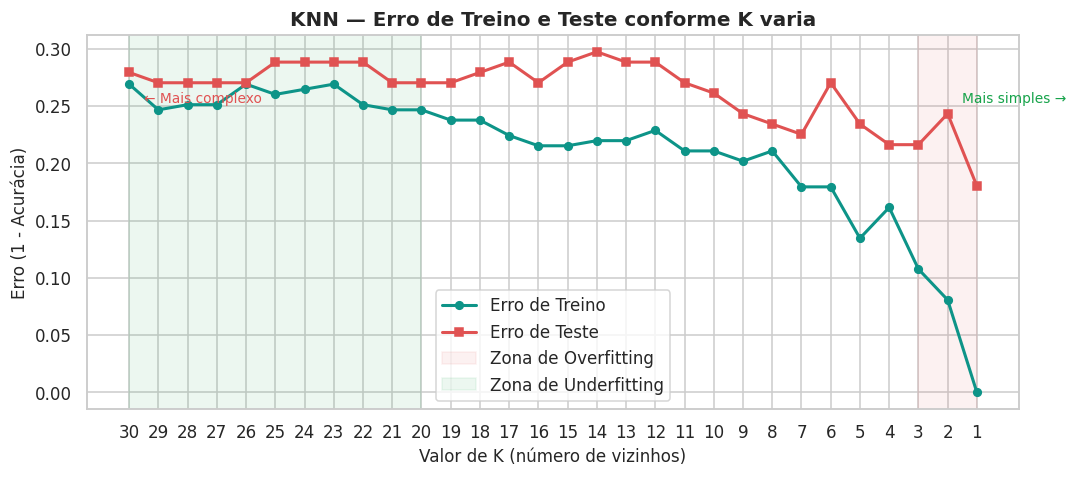

In [ ]:
ks = range(1, 31)
erros_treino_knn = []
erros_teste_knn  = []

for k in ks:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_treino, y_treino)
    erros_treino_knn.append(1 - accuracy_score(y_treino, modelo.predict(X_treino)))
    erros_teste_knn.append( 1 - accuracy_score(y_teste,  modelo.predict(X_teste)))

# Plotando
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(ks, erros_treino_knn, 'o-', color='#0D9488', linewidth=2, markersize=5, label='Erro de Treino')
ax.plot(ks, erros_teste_knn,  's-', color='#E05252', linewidth=2, markersize=5, label='Erro de Teste')

ax.axvspan(1, 3, alpha=0.08, color='#E05252', label='Zona de Overfitting')
ax.axvspan(20, 30, alpha=0.08, color='#16A34A', label='Zona de Underfitting')

ax.set_xlabel('Valor de K (número de vizinhos)', fontsize=11)
ax.set_ylabel('Erro (1 - Acurácia)', fontsize=11)
ax.set_title('KNN — Erro de Treino e Teste conforme K varia', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(list(ks))

# Invertendo o eixo X para que K pequeno (mais complexo) fique à esquerda
ax.invert_xaxis()
ax.text(29.5, max(erros_teste_knn)*0.85, '← Mais complexo', fontsize=9, color='#E05252')
ax.text(1.5,  max(erros_teste_knn)*0.85, 'Mais simples →',  fontsize=9, color='#16A34A')

plt.tight_layout()
plt.show()

**O que você vê no gráfico?**
- **K=1** (extrema esquerda): o erro de treino é **0** (o modelo memoriza tudo!), mas o erro de teste é alto → **overfitting**
- **K muito alto** (extrema direita): o erro de treino sobe → **underfitting**
- Existe um **ponto ideal** em algum K intermediário — menor erro de teste

Isso é exatamente a **curva viés-variância** que vimos na aula teórica!

In [ ]:
# Qual K teve o menor erro de teste?
melhor_k = list(ks)[np.argmin(erros_teste_knn)]
print(f"Melhor K encontrado: {melhor_k}")
print(f"  Erro de treino: {erros_treino_knn[melhor_k-1]:.2%}")
print(f"  Erro de teste:  {erros_teste_knn[melhor_k-1]:.2%}")

Melhor K encontrado: 1
  Erro de treino: 0.00%
  Erro de teste:  18.02%


### Experimento B — Árvore de Decisão: variando a profundidade

Agora fazemos o mesmo experimento com a Árvore de Decisão, variando o `max_depth`.

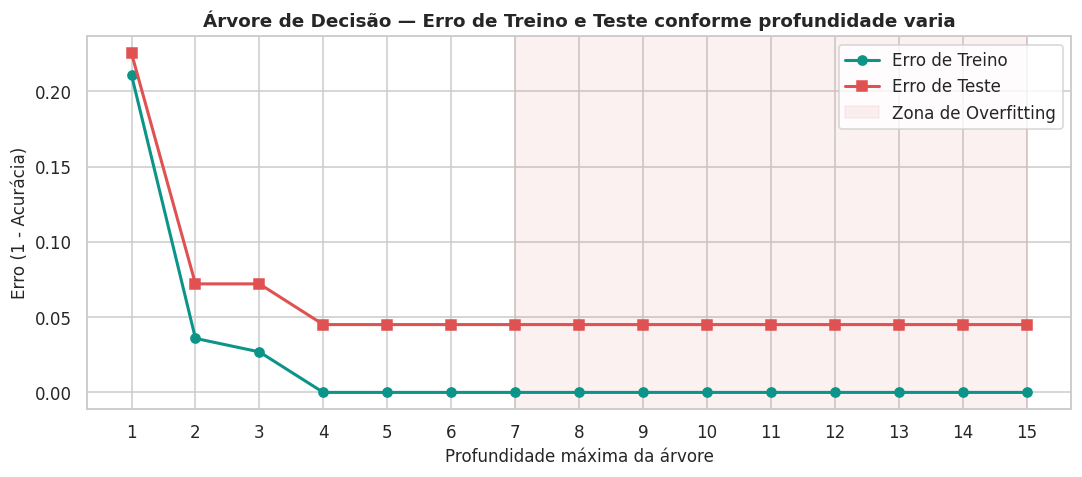

In [ ]:
profundidades = range(1, 16)
erros_treino_tree = []
erros_teste_tree  = []

for prof in profundidades:
    modelo = DecisionTreeClassifier(max_depth=prof, random_state=42)
    modelo.fit(X_treino, y_treino)
    erros_treino_tree.append(1 - accuracy_score(y_treino, modelo.predict(X_treino)))
    erros_teste_tree.append( 1 - accuracy_score(y_teste,  modelo.predict(X_teste)))

# Plotando
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(profundidades, erros_treino_tree, 'o-', color='#0D9488', linewidth=2, markersize=6, label='Erro de Treino')
ax.plot(profundidades, erros_teste_tree,  's-', color='#E05252', linewidth=2, markersize=6, label='Erro de Teste')

ax.axvspan(7, 15, alpha=0.08, color='#E05252', label='Zona de Overfitting')

ax.set_xlabel('Profundidade máxima da árvore', fontsize=11)
ax.set_ylabel('Erro (1 - Acurácia)', fontsize=11)
ax.set_title('Árvore de Decisão — Erro de Treino e Teste conforme profundidade varia',
             fontsize=12, fontweight='bold')
ax.legend()
ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.show()

**O que você vê?**
- Com profundidade maior, o erro de treino cai para **0** — a árvore aprende a resposta exata de cada exemplo
- Mas o erro de teste **não melhora** (e pode piorar) com profundidade excessiva
- **Profundidades muito grandes = overfitting**

In [ ]:
# Resumo comparativo de todos os modelos testados
print("Resumo comparativo")
print("="*55)
print(f"{'Modelo':<35} {'Treino':>8} {'Teste':>8}")
print("-"*55)
print(f"{'KNN (K=5)':<35} {acuracia_knn_treino:>8.2%} {acuracia_knn_teste:>8.2%}")
print(f"{'Árvore de Decisão (max_depth=3)':<35} {acuracia_arvore_treino:>8.2%} {acuracia_arvore_teste:>8.2%}")

# Melhor de cada experimento
melhor_prof = list(profundidades)[np.argmin(erros_teste_tree)]
melhor_arvore = DecisionTreeClassifier(max_depth=melhor_prof, random_state=42)
melhor_arvore.fit(X_treino, y_treino)
ac_mt = accuracy_score(y_treino, melhor_arvore.predict(X_treino))
ac_me = accuracy_score(y_teste,  melhor_arvore.predict(X_teste))
print(f"{'Árvore de Decisão (melhor depth)':<35} {ac_mt:>8.2%} {ac_me:>8.2%}   ← depth={melhor_prof}")

melhor_knn_model = KNeighborsClassifier(n_neighbors=melhor_k)
melhor_knn_model.fit(X_treino, y_treino)
ac_kt = accuracy_score(y_treino, melhor_knn_model.predict(X_treino))
ac_ke = accuracy_score(y_teste,  melhor_knn_model.predict(X_teste))
print(f"{'KNN (melhor K)':<35} {ac_kt:>8.2%} {ac_ke:>8.2%}   ← K={melhor_k}")

print("="*55)
print("\n⚠️  Lembre-se: o conjunto de teste foi usado aqui para")
print("   comparar modelos — na prática, isso é feito com")
print("   um conjunto de VALIDAÇÃO. Veremos isso no Encontro 05.")

Resumo comparativo
Modelo                                Treino    Teste
-------------------------------------------------------
KNN (K=5)                             86.55%   76.58%
Árvore de Decisão (max_depth=3)       97.31%   92.79%
Árvore de Decisão (melhor depth)     100.00%   95.50%   ← depth=4
KNN (melhor K)                       100.00%   81.98%   ← K=1

⚠️  Lembre-se: o conjunto de teste foi usado aqui para
   comparar modelos — na prática, isso é feito com
   um conjunto de VALIDAÇÃO. Veremos isso no Encontro 05.


---
## Etapa 7 · Desafio Final

Agora é a sua vez de explorar! Pegue o dataset dos [pinguins](https://archive.ics.uci.edu/dataset/690/palmer+penguins-3), reexecute as etapas e elabore um mini relatório com seus achados.
